# BoatPhone — finding boats in the satellite pictures

**What you are reading.** This is the reproducible record of how boats were detected in the
26 PlanetScope photographs that `optical_acquisition_pipeline.ipynb` acquired. It is written
to be read top to bottom by somebody who has never seen this repository.

Unusually, **most of this notebook is about things that did not work.** That is deliberate.
Four approaches were tried and abandoned, each for a specific measured reason, and a future
scientist who does not know those reasons will try them again. Section 5 is the honest
sequence, in order, with the measurement that retired each one.

---

## The project in one paragraph

Satellites see every boat in a patch of ocean, but only for the fraction of a second the
satellite is overhead. A hydrophone — an underwater microphone — hears boats continuously but
cannot tell you how many there are. BoatPhone uses each to fix the other's blind spot: the
satellite pictures give *ground truth* for a handful of instants, and those instants are used
to check a boat count computed from the sound. If they agree, the sound can estimate traffic
continuously — including small recreational boats, which carry no radio transponder and are
invisible to conventional vessel tracking.

## What *this* notebook achieves

It turns 26 photographs into **a table of 41 probable boats**, each with a position, a
distance and a bearing to the hydrophone, and a timestamp — which is the thing the acoustic
half needs in order to check itself.

## The one fact that makes this hard

**A boat is two to four pixels.**

PlanetScope resolves about 3 metres per pixel. A 6-metre runabout is therefore 2 pixels; a
12-metre fishing boat is about 4. The size class this project cares about most — vessels under
12 metres, the ones with no radio transponder — sits **at or below the resolution limit**.

Two pixels have no shape. You cannot measure their length, their orientation or their outline.
Nearly everything that goes wrong below traces back to this one sentence.

## What this notebook does *not* establish — read before quoting a number

- **"41 detections against 42 counted" is not 98% accuracy.** It is 12 surplus detections
  cancelling 13 missed ones. Only 8 of 26 scenes are exactly right. See section 11.
- **The sizes in the output are meaningless.** Every detection is reported as over 12 metres,
  because the box the model draws is 3–4 times bigger than the object inside it. This is a
  statement about the box, not about the boats. See section 11.
- **The ground truth may itself be under-counted.** Two scenes recorded as having zero boats
  contain obvious bright compact objects. See section 10.

---
# 0. How to run this notebook

One switch, `RUN_HEAVY`. Everything that runs the neural network is slow on a processor
without a graphics card — the full detector pass over 26 scenes takes roughly 25 minutes,
and the calibration search that produced it took hours.

With `RUN_HEAVY = False` those steps **print the exact command** instead of running, and the
notebook reads the results already on disk. Cheap steps — reading a picture, measuring
brightness, plotting — run for real.

> ⚠️ **Outputs live outside git.** Detection results are written to `data/derived/`, which is
> deliberately not committed (it is large, and raw data is immutable here). On a fresh clone
> those folders are empty and the reading cells will say so and tell you which command
> regenerates them.

In [1]:
# --- Setup. Run this first. ---------------------------------------------------
RUN_HEAVY = False        # True to actually run the detector and the calibration search

import json, os, pathlib, subprocess, sys

REPO_ROOT = pathlib.Path.cwd()
if REPO_ROOT.name == "final_notebooks":
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "scripts"))   # the entry points import each other
os.chdir(REPO_ROOT)
NOTEBOOK_DIR = REPO_ROOT / "final_notebooks"

DERIVED = REPO_ROOT / "data" / "derived"
FINAL   = DERIVED / "detections_final"
CENSUS  = DERIVED / "census"
SHARED  = pathlib.Path("/home/jovyan/shared-public/boatphone_shared/planet_folger/downloads")

print("repository root:", REPO_ROOT)
print("imagery present:", SHARED.exists())

from IPython.display import HTML, Image, display

def rel_to_notebook(path):
    """A path as the notebook's own HTML output needs to see it (links resolve
    relative to final_notebooks/, not to the working directory)."""
    return os.path.relpath(pathlib.Path(path).resolve(), NOTEBOOK_DIR)

def link(path, label=None):
    path = pathlib.Path(path)
    return f'<a href="{rel_to_notebook(path)}" target="_blank">{label or path.name}</a>'

def show_folder(path, label=None):
    path = pathlib.Path(path)
    display(HTML(f"&#128193; {link(path, label or str(path))}"))
    print("   absolute path:", path.resolve())

def run_script(command, heavy=True, timeout=None):
    """Run one of the programs in scripts/ and show its output.

    If `heavy` is True and RUN_HEAVY is False, the command is PRINTED and not run.
    That is how this notebook stays readable without a 25-minute wait.
    """
    argv   = [sys.executable] + [str(a) for a in command]
    pretty = "python3 " + " ".join(str(a) for a in command)
    if heavy and not RUN_HEAVY:
        print("SKIPPED (set RUN_HEAVY = True to run this):\n    " + pretty)
        return None
    print("running:\n    " + pretty + "\n" + "-" * 72)
    result = subprocess.run(argv, cwd=REPO_ROOT, timeout=timeout,
                            capture_output=True, text=True)
    print(result.stdout[-8000:])
    if result.returncode != 0:
        # Errors surface. We never swallow a failure and carry on with a plausible number.
        print("STDERR:\n" + result.stderr[-4000:])
        raise RuntimeError(f"{pretty} exited {result.returncode}")
    return result.stdout

def need(path, how_to_make):
    """Report a missing derived file honestly instead of failing obscurely."""
    path = pathlib.Path(path)
    if path.exists():
        return True
    print(f"NOT ON DISK: {path.relative_to(REPO_ROOT)}")
    print(f"  regenerate with:  {how_to_make}")
    return False

repository root: /home/jovyan/ohw26_proj_BoatPhone
imagery present: True


---
# 1. What a PlanetScope picture actually is

Each delivered scene is a single photograph of our 10 × 10 km box, about 3,400 pixels square,
recording **four colours**: blue, green, red, and **near-infrared** — light just beyond what
the eye can see.

Near-infrared matters more than the visible colours here. Water absorbs infrared almost
completely, so the sea is nearly black in that band, while almost any solid object floating on
it is bright. That is a much stronger contrast than anything in visible colour.

Each scene was delivered in **two forms**, and the difference between them is the single most
important fact in this notebook:

| Form | What it is |
|---|---|
| **Top-of-atmosphere** | The brightness the satellite actually measured, atmosphere included. |
| **Surface reflectance** | The same picture after software has estimated the haze and subtracted it. |

Intuitively the second sounds better — it is "corrected". Over water it is a trap, and
section 5.4 is the measurement that shows why.

In [2]:
import numpy as np
import rasterio

# One scene, in both forms. This is the scene everything was first tested against.
SCENE = "20200730_192942_71_1059"

def scene_files(scene_id):
    """Locate the two forms of one scene plus its quality mask, wherever they live."""
    toa = list((SHARED / "folger_202608_toa").rglob(f"{scene_id}_3B_AnalyticMS_clip.tif"))
    sr  = list((SHARED / "folger_202608").rglob(f"{scene_id}_3B_AnalyticMS_SR_clip.tif"))
    return (toa[0] if toa else None), (sr[0] if sr else None)

toa_path, sr_path = scene_files(SCENE)
if toa_path is None:
    print("Imagery is not on this machine. See optical_acquisition_pipeline.ipynb section 12.")
else:
    with rasterio.open(sr_path) as src:
        print(f"scene           : {SCENE}")
        print(f"size            : {src.width} x {src.height} pixels, {src.count} colour bands")
        print(f"pixel size      : {abs(src.transform.a):.1f} m")
        print(f"map grid        : {src.crs}")
        print(f"\nA 6 m boat is {6/abs(src.transform.a):.1f} pixels across."
              f"  A 12 m boat is {12/abs(src.transform.a):.1f} pixels.")

scene           : 20200730_192942_71_1059
size            : 3429 x 3429 pixels, 4 colour bands
pixel size      : 3.0 m
map grid        : EPSG:32610

A 6 m boat is 2.0 pixels across.  A 12 m boat is 4.0 pixels.


---
# 2. The two ways to find a boat

Only two approaches are possible on a picture like this, and both were built.

### Detector A — a trained neural network, looking at colour
An off-the-shelf model, `yolo11s_tci.pt` from `mayrajeo/marine-vessel-yolo`, trained to draw
boxes around ships in **Sentinel-2** satellite imagery. It is used unmodified. Because it
expects a colour picture, our four-band data has to be converted into one — and *how* that
conversion is done turns out to matter enormously.

### Detector B — a brightness test on the infrared band
No model, no training, no downloads. Work out how bright typical water is in this scene, then
call anything sufficiently brighter than that a candidate. Group the bright pixels into blobs
and measure each blob.

Detector B looks like the safer choice: it is simple, it has no licence questions, and it
measures shape directly rather than drawing a box. It was tried first. Section 5.2 is what
happened.

---
# 3. The ground truth we score against

Two team members counted boats **by eye** in the imagery, producing
`data/validation/planet_scope_validations.csv`: one row per moment, one number per row.

Its limits, stated plainly, because everything downstream inherits them:

- **It is a count, not a set of positions.** So a detector can get the right *number* for a
  scene while pointing at entirely the wrong objects. This is not hypothetical — see section 10.
- **It is small.** 29 counted moments holding 44 boats, but three of those moments were
  never ordered as imagery — so the ground truth this notebook can actually score against
  is **26 moments and 42 boats**. Every accuracy figure below is against that 42.
- **It may under-count.** See section 10.

In [3]:
import csv
import pandas as pd

TRUTH_CSV = REPO_ROOT / "data" / "validation" / "planet_scope_validations.csv"
truth = {}
for row in csv.reader(open(TRUTH_CSV)):
    if not row or row[0].strip().lower().startswith("timestamp"):
        continue
    truth[row[0].strip()] = int(row[1])          # key is YYYYMMDD_HHMM

print(f"{len(truth)} counted moments, {sum(truth.values())} boats in the file")
print(f"moments with no boats at all: {sum(1 for v in truth.values() if v == 0)}")
print(f"most boats in one moment    : {max(truth.values())}")

# Three of the counted moments were never ordered as imagery (they were dropped from the
# batch in acquisition section 10), so the number this notebook can actually score
# against is smaller than the file total. Stated explicitly rather than left to be
# rediscovered as a mismatch later.
NO_IMAGERY = ["20230618_1824", "20240701_1937", "20250619_1948"]
scored = sum(v for k, v in truth.items() if k not in NO_IMAGERY)
print(f"\nof those, {len(NO_IMAGERY)} moments have no imagery: {NO_IMAGERY}")
print(f"so the scoreable ground truth is {len(truth)-len(NO_IMAGERY)} moments, {scored} boats")

29 counted moments, 44 boats in the file
moments with no boats at all: 6
most boats in one moment    : 4

of those, 3 moments have no imagery: ['20230618_1824', '20240701_1937', '20250619_1948']
so the scoreable ground truth is 26 moments, 42 boats


---
# 4. How the model is run over a big picture

The model expects a small square image, roughly 640 pixels on a side. Our scenes are 3,400.
So each scene is cut into overlapping 640-pixel tiles, the model runs on each, the resulting
boxes are shifted back into whole-scene coordinates, and duplicates from the overlap are merged.

Two choices in that paragraph were tested rather than assumed, and one of them is counter-intuitive:

- **Overlap of 20%** so that a boat straddling a tile edge is still wholly inside some tile.
- **No magnification.** The obvious idea is to cut *smaller* tiles and blow them up, so a 6-metre
  boat lands on more pixels. It was measured over all 26 scenes and it is **worse** — 546 boxes
  against 1,537, and lower accuracy. Enlarging a 2-pixel object invents no new information; it
  only makes the noise bigger too. The model does better at the picture's own scale.

All of this lives in `boatphone/vessel_detect.py` so that every notebook runs the same code.

---
# 5. What was tried, in order

This is the honest sequence. Each step ends with the measurement that killed it or kept it.

## 5.1 Detector A on Planet's own colour picture → **4 detections, no boats**

Planet ships a ready-made colour render. It is the obvious input, so it went first.

It found four blobs, all on the shoreline, with confidence 0.07–0.14, and **missed all three
boat wakes plainly visible in the picture**. The water in that render sits at brightness value
**1 out of 255** — essentially black. The model had nothing to work with.

## 5.2 Detector B on infrared → **32,877 detections**

That is about **1,265 per scene**, over a patch of ocean expected to hold one or two boats.

The threshold was "brighter than the typical water by some multiple of the spread of the
water's brightness" — a standard, statistically respectable rule. The median detected length
came out at 7.2 metres against a 6-metre floor, which is the signature of a length
distribution that is just the smallest thing the method can see, repeated.

## 5.3 Why Detector B could not be rescued by tuning → **the knob is dead**

This is the most important negative result on this side of the project, and it is worth
understanding rather than just avoiding.

That threshold rule assumes the brightness of water follows a bell curve. **Over the ocean it
does not.** Raising the threshold from 6× the spread to 10× should, on a bell curve, remove
essentially everything — a factor of 10¹⁴. Measured across all 26 scenes it removes a factor
of **2.03**. Every scene, no exceptions. There is no threshold value that separates boats from
noise, so no amount of sweeping the knob will find one.

Worse, the resulting count is **not measuring boats at all**. Across the 26 scenes the
roughness of the sea surface varies by a factor of 5.1. That 5.1 becomes a factor of **258** in
the number of detections — 32 in the roughest scene, 8,257 in the calmest. The correlation
between detections and sea-surface roughness is −0.88.

> **A detector whose count is set by how choppy the water is, is not counting boats.**

A related data-quality problem surfaced in the same test: one scene, `20250825_193929_84_251f`,
has 65% of its water pixels pinned at exactly the same value — the floor of the haze-removal
software. Its statistics are meaningless and it should not be pooled with the others.

## 5.4 Detector A on haze-removed imagery → **still poor**, and the reason is the fix

Back to the neural network, this time on the four-band data converted to colour with a fixed
recipe. Water landed at brightness 13. Better than 1, still far too dark, mostly shoreline
detections.

## 5.5 Detector A on top-of-atmosphere imagery → **the breakthrough**

The model was trained on **Sentinel-2 Level-1C**, which is *top-of-atmosphere* imagery — the
brightness as measured, atmosphere and all. In Sentinel-2 pictures, water sits around
brightness 50–100.

Over water, the atmosphere is *most of what the satellite sees*. So "correcting" the picture by
removing the haze removes the bulk of what the model was trained to recognise. Feeding it the
uncorrected picture instead put water at brightness **50.0** — right in the range the model
expects — and **all three visible wakes were detected at confidence 0.51–0.63**, having been
missed entirely by every previous attempt.

| Input | Water brightness | Boxes kept | What they were on |
|---|---|---|---|
| Top-of-atmosphere | **about 50** | 46 | **all three wakes**, plus island false alarms |
| Haze-removed | about 14 | 17 | mostly shoreline |
| Planet's colour render | about 1 | 4 | four shoreline blobs, no wakes |

The brightness column is reproduced live in the cell below. The box counts come from the
original three-way comparison, `scripts/detector_a_toa_test.py`, which runs the model on all
three inputs at once — rerun it if you want to reproduce those too.

**The count is not the result. The *location* is.** Real boats went from undetected to
confidently detected — a different kind of change from "more detections".

> ⚠️ **The trap inside the fix.** The top-of-atmosphere file is *radiance*, not reflectance.
> Applying the colour recipe to it directly saturates the picture — water at 236 out of 255 and
> a meaningless answer. Each scene's metadata carries a per-band conversion factor (about
> 2 × 10⁻⁵) that must be applied first. The haze-removed file needs no such factor. That
> asymmetry is silent: you get a picture either way.

## 5.6 Using Detector A for location and Detector B for size → **abandoned**

Since A finds *where* a moving boat is (by its wake) and B measures *shape*, the natural move is
to run B inside a window around each of A's boxes.

It fails on the step that has to decide which blob in the window is the boat. Picking the
brightest picks the wake foam, which is bright in infrared. Picking the most compact picks
2-pixel specks, because a 2-pixel blob fills its own bounding rectangle exactly by construction.
Both rules are degenerate, at opposite ends of the size range. Retired to `superseded/optical/`.

## 5.7 What finally worked → **make the two forms of the same picture agree**

The insight is that top-of-atmosphere and haze-removed are **the same acquisition** — same
water, same boats, same instant — rendered two ways. They fail *differently*. So a box that
appears in only one of them is uncorroborated, and a box that appears in both, in the same
place, is corroborated by something the model itself could not fake.

Run the model on both, then keep only boxes that agree to within 30 metres.

Measured: the network on one form alone tops out around **0.15** on the accuracy score used for
tuning. Requiring both to agree reaches **0.41**. The agreement requirement, not the threshold,
is what does the work.

In [4]:
# Reproduce the central measurement of section 5.5 on one scene. This is cheap — two
# raster reads and some arithmetic — and it is the result everything else rests on.
from boatphone import optical

if toa_path is None:
    print("Imagery not on this machine; skipping the live measurement.")
else:
    import xml.etree.ElementTree as ET

    def reflectance_factors(xml_path):
        """Per-band conversion from top-of-atmosphere RADIANCE counts to reflectance.

        This is the factor described in the warning above. Without it the colour
        recipe saturates and the whole picture is white.
        """
        root = ET.parse(xml_path).getroot()
        out = {}
        for node in root.iter():
            if node.tag.endswith("bandSpecificMetadata"):
                band = coef = None
                for child in node:
                    if child.tag.endswith("bandNumber"):            band = int(child.text)
                    if child.tag.endswith("reflectanceCoefficient"): coef = float(child.text)
                if band and coef:
                    out[band] = coef
        return out

    def water_brightness(path, water, factors=None):
        """Median brightness OF THE WATER, on the same 0-255 scale the model was trained on.

        The recipe is fixed and global -- reflectance x 1000, clipped -- NOT a stretch
        computed from the picture's own contents. That matters: a per-scene stretch would
        make a scene's brightness depend on what happens to be in it.

        Measured over water only, not the whole picture: the islands in the corner are
        bright and would pull the median up by about half a point.
        """
        with rasterio.open(path) as src:
            bands = src.read().astype(np.float32)
        if factors is None:
            reflectance = bands / optical.PLANET_QUANT           # already reflectance x 10000
        else:
            reflectance = np.stack([bands[i] * factors[i + 1] for i in range(4)])
        eight_bit = np.clip(reflectance[[2, 1, 0]] * (optical.PLANET_QUANT / optical.TCI_DIVISOR),
                            0, 255)
        return float(np.median(eight_bit[:, water]))

    # The shared water mask: land is defined by EXTENT, not brightness (decision 0017).
    with rasterio.open(sr_path) as src:
        sr_bands = src.read().astype(np.float32) / optical.PLANET_QUANT
        res_m    = abs(src.transform.a)
    valid = sr_bands.sum(0) > 0
    water, _ = optical.water_mask(sr_bands[1], sr_bands[3], valid, None, res_m=res_m)

    xml = str(toa_path).replace("_AnalyticMS_clip.tif", "_AnalyticMS_metadata_clip.xml")
    toa_dn = water_brightness(toa_path, water, reflectance_factors(xml))
    sr_dn  = water_brightness(sr_path,  water, None)

    print(f"scene {SCENE}, median brightness on the model's 0-255 scale:\n")
    print(f"  top-of-atmosphere : {toa_dn:5.1f}   <- what the model was trained on (~50-100)")
    print(f"  haze-removed      : {sr_dn:5.1f}   <- {toa_dn/sr_dn:.1f}x too dark")
    print(f"\nBoth pictures are the same instant. The difference is the product, not the recipe:")
    print(f"the identical conversion was applied to each.")

scene 20200730_192942_71_1059, median brightness on the model's 0-255 scale:

  top-of-atmosphere :  50.5   <- what the model was trained on (~50-100)
  haze-removed      :  13.8   <- 3.7x too dark

Both pictures are the same instant. The difference is the product, not the recipe:
the identical conversion was applied to each.


---
# 6. Calibrating against the human counts

With the agreement idea in hand, two numbers still had to be chosen: how confident the model
must be on each of the two forms before a box counts.

The search runs the model **once** per scene at a deliberately low confidence and caches every
box it produces. Confidence, size limits and masks are all filters applied *afterwards*, so
sweeping them costs no further model runs — hours of work becomes seconds.

In [5]:
print("The calibration chain, in order. Each script's own docstring explains its reasoning.\n")
for script, what in (
    ("sweep_cache.py",    "run the model ONCE per scene at a low confidence, cache every box"),
    ("sweep_features.py", "attach evidence the model could not have used (infrared, distance to shore)"),
    ("sweep_score.py",    "sweep the filters over the cache and score against the human counts"),
    ("sweep_validate.py", "the honesty checks: shuffled labels, and a held-out half"),
):
    print(f"  scripts/{script:<20} {what}")

print()
run_script(["scripts/sweep_cache.py", "--cache-dir", "data/derived/boxcache",
            "--assets", "toa", "sr", "--slice", "640", "--imgsz", "640", "--order", "bgr"],
           heavy=True)

The calibration chain, in order. Each script's own docstring explains its reasoning.

  scripts/sweep_cache.py       run the model ONCE per scene at a low confidence, cache every box
  scripts/sweep_features.py    attach evidence the model could not have used (infrared, distance to shore)
  scripts/sweep_score.py       sweep the filters over the cache and score against the human counts
  scripts/sweep_validate.py    the honesty checks: shuffled labels, and a held-out half

SKIPPED (set RUN_HEAVY = True to run this):
    python3 scripts/sweep_cache.py --cache-dir data/derived/boxcache --assets toa sr --slice 640 --imgsz 640 --order bgr


---
# 7. The check that changed the design

This is the part worth copying into other projects.

The first search had **eight free parameters over 24,192 combinations**. It reached an accuracy
of **0.452**. That looked like a good result.

It was not. Two checks were run, and both re-ran the *entire selection procedure* rather than
re-scoring the winner:

| Check | What it does | Result |
|---|---|---|
| **Shuffled labels** | Randomly reassign the human counts to the wrong scenes, then run the whole search again. Whatever it achieves is the floor that means nothing. | **0.237** |
| **Held-out half** | Choose the settings using a random half of the scenes; score on the other half. | **0.232** |

The held-out score of the eight-knob search, 0.232, is **indistinguishable from the score
achieved on deliberately scrambled labels**, 0.237. The search had been fitting noise.

Cutting the search to **two** free parameters — one confidence per form, 42 combinations —
scored the same on total count, *better* on per-scene agreement, and overfitted measurably less:

| Search size | Score, all 26 scenes | Score, held out | Overfit gap |
|---|---|---|---|
| 8 knobs, 24,192 combinations | 0.452 | 0.232 | 0.271 |
| **2 knobs, 42 combinations** | 0.41 | — | **0.198** |

With 26 scenes and 42 boats, **every extra knob costs more in selection noise than it buys**.
The same configuration wins at all three search sizes, which is the stability check worth having
before believing any of it.

> This is why the shipped detector is simpler than the one that scored best.

In [6]:
# The honesty checks are a script, not a paragraph. Re-run them to reproduce the table above.
run_script(["scripts/sweep_validate.py"], heavy=True, timeout=7200)

SKIPPED (set RUN_HEAVY = True to run this):
    python3 scripts/sweep_validate.py


---
# 8. The detector that shipped

Every value below was measured, not argued.

| Setting | Value | Why |
|---|---|---|
| Tile size | 640 pixels, no magnification | Enlarging measured *worse* (section 4) |
| Confidence, top-of-atmosphere | 0.45 | One of the two tuned parameters |
| Confidence, haze-removed | 0.075 | The two forms differ ~4× in brightness, so they need different thresholds |
| Agreement | both must see it within 30 m | **This is what does the work** |
| Maximum length | 40 m | An implausibility bound, not a science threshold |

Two things that were expected to help and **measurably did not**, recorded so nobody repeats them:

- **The water mask.** Masking out land removes almost nothing here — our box is about 92% water,
  so it changed 450 boxes to 453. It is reported in the output but not applied.
- **Infrared support, distance from shore, and repeat-location filtering.** Each moved the score
  by less than the noise in the measurement itself, so none is in the shipped configuration.

In [7]:
run_script(["scripts/detect_vessels_final.py",
            "--out-dir", "data/derived/detections_final",
            "--preview-dir", "data/derived/detections_final/previews"],
           heavy=True, timeout=7200)

SKIPPED (set RUN_HEAVY = True to run this):
    python3 scripts/detect_vessels_final.py --out-dir data/derived/detections_final --preview-dir data/derived/detections_final/previews


---
# 9. The output

Two files, and one of them is the deliverable the acoustic half consumes.

| File | One row per | What it carries |
|---|---|---|
| `detections_final.csv` | probable boat | position, **distance and bearing to the hydrophone**, timestamp, confidence |
| `scenes_final.csv` | acquisition | how many boats, distance to the nearest one, water brightness |

`range_km` is the column the acoustic side needs: sound falls off with distance, so a boat's
distance is what lets a measured loudness be compared against a predicted one.

> 🛰️ **HANDOFF — still open, and every distance depends on it.** Distances are measured from
> `optical.HYDROPHONE_LONLAT`, which is currently **the centre of the study box, not confirmed
> instrument metadata**. A claimed position from the observatory sits 272 m away — a 32% error
> at a range of 0.84 km. The observatory also records the position *per deployment*, so no
> single coordinate can be right across six years. Settling it needs
> `getDeployments(deviceCode="ICLISTENHF1266")` run with an account token. **Every `range_km`
> in this file moves if that coordinate moves.**

In [8]:
if need(FINAL / "detections_final.csv",
        "python3 scripts/detect_vessels_final.py --out-dir data/derived/detections_final"):
    det    = pd.read_csv(FINAL / "detections_final.csv")
    scenes = pd.read_csv(FINAL / "scenes_final.csv")
    print(f"{len(det)} probable boats over {len(scenes)} scenes\n")
    print(det[["scene_id", "acq_time_utc", "lon", "lat", "range_km", "bearing_deg",
               "conf_toa", "conf_sr"]].head(8).to_string(index=False))
    print(f"\ndistance to the hydrophone: {det['range_km'].min():.2f} to "
          f"{det['range_km'].max():.2f} km")
    show_folder(FINAL, "detection outputs, including one annotated preview per scene")
else:
    det = scenes = None

41 probable boats over 26 scenes

               scene_id         acq_time_utc         lon       lat  range_km  bearing_deg  conf_toa  conf_sr
20200730_192942_71_1059 2020-07-30T19:29:42Z -125.242591 48.833523     3.389         50.6    0.6675   0.1693
20200730_192942_71_1059 2020-07-30T19:29:42Z -125.226029 48.846899     5.286         46.5    0.4714   0.2466
20200730_192942_71_1059 2020-07-30T19:29:42Z -125.232992 48.821240     3.417         76.7    0.6124   0.3696
20200730_192942_71_1059 2020-07-30T19:29:42Z -125.238810 48.829427     3.357         59.7    0.4560   0.1819
20200730_192942_71_1059 2020-07-30T19:29:42Z -125.323365 48.844061     4.689        315.1    0.5382   0.5535
20210730_182659_13_2434 2021-07-30T18:26:59Z -125.255738 48.774688     4.696        159.3    0.5799   0.4024
20210812_191832_32_2406 2021-08-12T19:18:32Z -125.315493 48.849926     4.822        325.5    0.5589   0.1455
20210812_191832_32_2406 2021-08-12T19:18:32Z -125.280136 48.833320     2.131        356.3    0

   absolute path: /home/jovyan/ohw26_proj_BoatPhone/data/derived/detections_final


---
# 10. Checking the boxes, not just the count

The detector was tuned against a *count per scene*. That means a scene can carry the right
number of boats for entirely the wrong reasons. The only way to know is to look at every box.

`scripts/census_chips.py` renders that review: five panels per detection — the two forms of the
picture at 300 m across, the infrared band stretched so faint objects show, and then both at
75 m across and 20× magnification, where a 2–3 pixel object is finally resolvable.

A real boat should be a **compact bright object in all of them, in open water**. A rock is
bright in infrared too but appears in the same place every year. Foam is bright in one form and
not the other. A shoreline artefact sits against land.

All 41 detections were reviewed:

| Verdict | Count | What it means |
|---|---|---|
| Boat | 24 | Compact bright core in every panel, in open water |
| Probably a boat | 9 | Same, but weakened by a quantised infrared band, a nearby cloud, or a scene edge |
| Ambiguous | 5 | Something is there, but diffuse or offset from the box |
| **Not a boat** | **3** | See below |

The three rejects: one box is dark in infrared, 400 m off a headland; one sits on a hazy scene
with no object visible in either form; one is an empty box 90 m away from the real object,
which was detected separately.

> ⚠️ **This was an automated review, not a human one.** It narrows the human job to the 8
> non-"boat" rows rather than replacing it. The verdicts are in
> `data/derived/census/census_agent_review.csv`, and `census_index.csv` beside it has **empty
> verdict columns** for a person to fill in independently.

### The ground truth may itself be under-counted

Two scenes — `20230714_182421_54_24b6` and `20220725_185511_20_248e` — are recorded in the
truth file as containing **zero** boats, and both contain obvious compact bright objects at
3–7× the brightness of the surrounding water, clearly visible at 20× magnification.

If the human count was made on downscaled previews, a 2-pixel hull is not resolvable — which
means **the thing we calibrated against may share the exact small-boat blind spot we are trying
to measure**. Worth re-checking those two scenes at full resolution before trusting the 42.

### A negative result, so nobody chases it

While reviewing, the infrared blob appeared to sit consistently up and to the right of the box,
which raised the possibility of a timing offset between colour bands on a moving hull — which
would have been a way to tell moving boats from static objects.

**It is not there.** Measured over all 41 detections, the offset between the visible and
infrared brightness peaks is a median of 0.52 pixels (1.6 m), and it is *identical* whether
measured between two bands of the same file or across the two different files. So there is no
misalignment to correct, and no usable motion signal at this resolution. What the eye was
seeing is simply that the box is loose around a 2–3 pixel core.

In [9]:
run_script(["scripts/census_chips.py", "--out-dir", "data/derived/census"], heavy=True, timeout=3600)

SKIPPED (set RUN_HEAVY = True to run this):
    python3 scripts/census_chips.py --out-dir data/derived/census


In [10]:
if need(CENSUS / "census_agent_review.csv",
        "python3 scripts/census_chips.py --out-dir data/derived/census   (then review the sheets)"):
    review = pd.read_csv(CENSUS / "census_agent_review.csv")
    print(review["verdict"].value_counts().to_string(), "\n")
    print("Everything not judged a clear boat — this is the list a human should settle:\n")
    print(review[review["verdict"] != "vessel"][
        ["det_index", "scene_id", "verdict", "range_km", "nir_x_water"]].to_string(index=False))
    show_folder(CENSUS, "review sheets, one PNG per scene, five panels per detection")

verdict
vessel           24
likely_vessel     9
ambiguous         5
not_vessel        3 

Everything not judged a clear boat — this is the list a human should settle:

 det_index                scene_id       verdict  range_km  nir_x_water
         1 20200730_192942_71_1059     ambiguous     5.286          2.3
         3 20200730_192942_71_1059    not_vessel     3.357          1.9
         6 20210812_191832_32_2406 likely_vessel     4.822          4.8
         7 20210812_191832_32_2406 likely_vessel     2.131          9.5
         8 20210812_194340_68_1058     ambiguous     4.960          2.5
        10 20210812_194340_68_1058 likely_vessel     5.025          5.8
        14 20210824_181728_61_1067 likely_vessel     4.371          4.8
        15 20210824_181728_61_1067 likely_vessel     5.187          5.0
        17 20220625_182034_44_2440     ambiguous     0.975          1.4
        18 20220625_182034_44_2440 likely_vessel     5.160          2.5
        25 20230617_185923_93_247a    no

   absolute path: /home/jovyan/ohw26_proj_BoatPhone/data/derived/census


In [11]:
# The other half of the census: the boxes the AGREEMENT RULE discarded. One rendering saw
# them and the other did not, so they were dropped -- whether they were foam or a boat.
# Reviewing these is what would say whether that rule is costing real boats.
#
# It reads the cached model output rather than re-running the network, so what it calls
# "discarded" is exactly what the shipped detector dropped, not a reimplementation.
run_script(["scripts/census_misses.py",
            "--cache-dir", "data/derived/boxcache",
            "--out-dir", "data/derived/census/misses",
            "--only-shortfall", "--top", "4"], heavy=True, timeout=3600)

if (CENSUS / "misses" / "misses_index.csv").exists():
    misses = pd.read_csv(CENSUS / "misses" / "misses_index.csv")
    print(f"\n{len(misses)} discarded boxes rendered over "
          f"{misses['scene_id'].nunique()} scenes where boats were missed")
    print(misses.groupby("asset").size().to_string())
    show_folder(CENSUS / "misses", "the discarded boxes, awaiting a human verdict")

SKIPPED (set RUN_HEAVY = True to run this):
    python3 scripts/census_misses.py --cache-dir data/derived/boxcache --out-dir data/derived/census/misses --only-shortfall --top 4

37 discarded boxes rendered over 10 scenes where boats were missed
asset
sr_only     14
toa_only    23


   absolute path: /home/jovyan/ohw26_proj_BoatPhone/data/derived/census/misses


---
# 11. What the numbers mean, and what they do not

### "41 against 42" is a cancellation, not an accuracy

Across the 26 scenes the detector reports 41 boats and the humans counted 42. That is a 97.6%
agreement **on the total**, and it is close to meaningless as a measure of the detector,
because it is 12 surplus detections cancelling 13 missed ones.

The honest figures:

| Measure | Value |
|---|---|
| Scenes exactly right | 8 of 26 (31%) |
| Scenes right to within one boat | 20 of 26 (77%) |
| Average error per scene | 0.96 boats |
| Agreement between per-scene counts | correlation 0.675 |

Anyone joining this to the acoustic data should use `scenes_final.csv`, treat `n_vessels` as a
*candidate* count, and **not** read the individual rows as a verified census.

### The sizes are an artefact of the box, not a property of the fleet

Every one of the 41 detections is reported as over 12 metres — 35 as over 24 m, 6 between 12
and 24 m — and **none** in the under-12-metre class this project cares about most.

That is not a finding about the boats. The objects are 2–3 pixels of brightness; the box the
model draws around them is 8–12 pixels. At 3 metres per pixel that renders a small runabout as
a "23–37 metre" vessel.

> **Do not read "no boats under 12 m" as "no small boats present."** The human counts say small
> boats *are* there. The `length_m` column is fit for the 40-metre implausibility cut it was
> tuned for and for nothing else. A real size distribution would need a shape-fitting step, not
> the network's box.

### The deeper limit, which is about the sensor and not our code

A 6-metre boat is 2 pixels; a 12-metre boat is about 4. The under-12-metre class sits **at or
below the resolution limit**. The threshold cannot simply be raised to remove noise without
deleting the target class, and no shape test is available on 2–4 pixels either.

For the smallest size class, PlanetScope may support detecting that *something* is there — and
particularly detecting its *absence* over repeat visits — but not identifying individual boats
scene by scene. That is a claim about the satellite, not about this software.

In [12]:
# The per-scene picture behind the headline. One row per scene, sorted by date.
if det is not None:
    rows = []
    for _, s in scenes.iterrows():
        counted = truth.get(s["scene_id"][:13])
        if counted is not None:
            rows.append({"scene_id": s["scene_id"], "date": s["acq_time_utc"][:10],
                         "counted_by_eye": counted, "detected": int(s["n_vessels"]),
                         "difference": int(s["n_vessels"]) - counted})
    comp = pd.DataFrame(rows).sort_values("date").reset_index(drop=True)

    over  = comp[comp["difference"] > 0]["difference"].sum()
    under = -comp[comp["difference"] < 0]["difference"].sum()
    print(f"counted by eye : {comp['counted_by_eye'].sum()}")
    print(f"detected       : {comp['detected'].sum()}")
    print(f"\nsurplus detections : +{over}")
    print(f"missed boats       : -{under}")
    print(f"                     -> they cancel to {comp['detected'].sum() - comp['counted_by_eye'].sum():+d}")
    print(f"\nexactly right      : {(comp['difference'] == 0).sum()} of {len(comp)} scenes")
    print(f"right within one   : {(comp['difference'].abs() <= 1).sum()} of {len(comp)} scenes")

counted by eye : 42
detected       : 41

surplus detections : +12
missed boats       : -13
                     -> they cancel to -1

exactly right      : 8 of 26 scenes
right within one   : 20 of 26 scenes


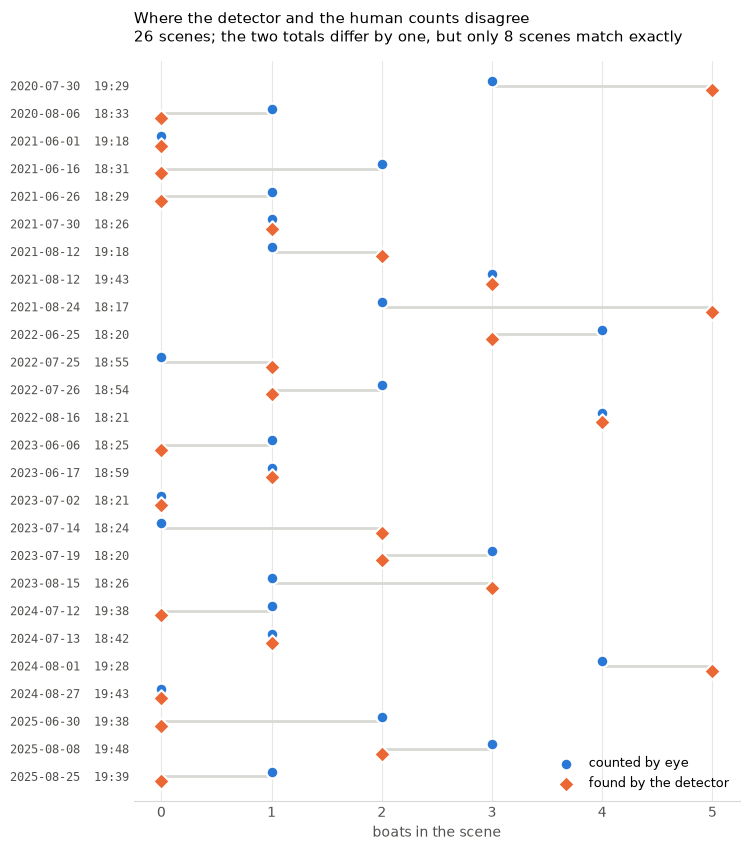

In [13]:
# One figure: what the headline hides. A line per scene from the human count to the
# detector's count, so agreement is a dot and disagreement is a visible span.
import matplotlib.pyplot as plt

if det is not None:
    # Two categorical hues, taken unchanged from the project's validated reference
    # palette (slots 1 and 2). Identity is never carried by colour alone here: the two
    # series are also separated by marker shape and named in the legend.
    COUNTED, DETECTED, RULE, INK = "#2a78d6", "#eb6834", "#d8d8d4", "#52514e"

    d = comp.iloc[::-1].reset_index(drop=True)          # earliest at the top
    y = np.arange(len(d))
    fig, ax = plt.subplots(figsize=(7.6, 8.6))

    # The two series are nudged apart vertically. Without the nudge, a scene where the
    # counts AGREE draws one marker exactly on top of the other, and perfect agreement
    # becomes indistinguishable from "only the detector saw anything" -- which would
    # hide the eight scenes that are the good news in this chart.
    NUDGE = 0.17
    ax.hlines(y, d["counted_by_eye"], d["detected"], color=RULE, lw=2, zorder=1)
    ax.scatter(d["counted_by_eye"], y + NUDGE, s=70, color=COUNTED, marker="o", zorder=3,
               edgecolors="white", linewidths=1.5, label="counted by eye")
    ax.scatter(d["detected"], y - NUDGE, s=70, color=DETECTED, marker="D", zorder=3,
               edgecolors="white", linewidths=1.5, label="found by the detector")

    ax.set_yticks(list(y))
    # Two pairs of scenes fall on the same day, 25 minutes apart on different satellites,
    # so the label carries the time as well -- they are separate observations.
    ax.set_yticklabels([f"{r.date}  {r.scene_id[9:11]}:{r.scene_id[11:13]}"
                        for r in d.itertuples()], fontsize=8.5, color=INK,
                       fontfamily="monospace")
    ax.set_xlabel("boats in the scene", fontsize=10, color=INK)
    ax.set_xticks(range(0, 6))
    ax.set_title("Where the detector and the human counts disagree\n"
                 "26 scenes; the two totals differ by one, but only 8 scenes match exactly",
                 fontsize=11, loc="left", pad=14)
    ax.legend(frameon=False, loc="lower right", fontsize=9)
    ax.set_ylim(-0.9, len(d) - 0.1)

    ax.grid(axis="x", color=RULE, lw=0.8, alpha=0.6)    # recessive grid
    ax.set_axisbelow(True)
    for side in ("top", "right", "left"):
        ax.spines[side].set_visible(False)
    ax.spines["bottom"].set_color(RULE)
    ax.tick_params(length=0, colors=INK)
    plt.tight_layout()
    plt.show()

---
# 12. Where this connects to the sound

The acoustic notebook flags four places where it needs something from this side. Their status:

| Handoff | Status |
|---|---|
| **Do not order 2026 imagery** — no sound exists after 14 March 2026 | ✅ **Answered.** The search covered 2020–2025 only, and every ordered scene was checked against the recorded outages before spending. |
| **More labelled moments are the top priority** | ⚠️ **Open, and now urgent for a second reason.** 29 moments with six empty ones cannot separate a real estimator from a lucky one — *and* section 10 gives reason to think the existing counts miss small boats. Re-counting the current 26 at full resolution is cheaper than acquiring more, and should come first. |
| **The hydrophone coordinate** | ⚠️ **Open.** See section 9. Needs an account token and one API call. |
| **Fill `planet_scene/` in the review sheets** | ⚠️ **Open.** For each acoustic review window, this side should supply the clipped picture and its detection overlay. The pictures exist (`data/derived/detections_final/previews/`); nobody has wired them into the acoustic review folders. |

---
# 13. What a future scientist should do first

In order, cheapest and most valuable first.

1. **Re-count the 26 scenes at full resolution.** Section 10 gives specific evidence the ground
   truth misses small boats. Everything here is calibrated against that truth, so if it is
   biased, so is the detector — and this costs nothing but attention.
2. **Settle the hydrophone coordinate.** One API call. Every distance in the output depends on it.
3. **Finish the human census.** 8 detections need a person's verdict; the review sheets are
   rendered and waiting. Also review the discarded boxes in `data/derived/census/misses/` — 37
   boxes that one form saw and the other did not, over the 10 scenes where boats were missed.
   That is what would say whether the agreement rule is costing real boats or working as intended.
4. **Do not re-try Detector B.** Section 5.3 is not a tuning problem.
5. **Do not re-try magnifying the tiles.** Section 4.

---
# Where to go next

| Notebook | What it covers |
|---|---|
| `optical_acquisition_pipeline.ipynb` | How these 26 photographs were found, screened and paid for. |
| `acoustic_pipeline.ipynb` | The underwater microphone half — recordings, loudness, counting passages by sound. |

**Retired approaches** are in `superseded/optical/`, kept on disk but out of git. Its README
lists each file and the measurement that retired it. Nothing there is worth reviving without
reading section 5 first.

**Decision records** in `docs/decisions/` carry the durable choices, including 0016 (the size
classes and why the length bound is an implausibility cut) and 0017 (why land is defined by
extent rather than brightness).